# Semantic Matching Evaluation

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.exists(os.path.join(os.getcwd(), "catalogue.csv")):
    ROOT = os.path.abspath(os.getcwd())
sys.path.insert(0, os.path.join(ROOT, "src"))

from semantic_matcher.metrics import mean_reciprocal_rank, recall_at_k
from semantic_matcher.retrieval import SemanticMatcher

c:\Users\safwe\Desktop\Project 2 NLP Sementic Search\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data and Run Evaluation

In [3]:
queries_path = os.path.join(ROOT, "queries.csv")
artifacts_dir = os.path.join(ROOT, "artifacts")

df = pd.read_csv(queries_path)
matcher = SemanticMatcher.from_artifacts(artifacts_dir)

print(f"Total queries: {len(df)}")
print(f"Model: {matcher.config.model_name}")
print(f"Index version: {matcher.config.index_version}")

Total queries: 1110
Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Index version: 1.0.0


In [4]:
ranked_lists = []
truths = []
all_scores = []
all_confidences = []
match_modes = []
query_lengths = []
correct_ranks = []

for row in df.itertuples(index=False):
    results = matcher.match(row.query_text, top_k=10)
    ranked_ids = [result["item_id"] for result in results]
    ranked_lists.append(ranked_ids)
    truths.append(row.item_id)
    
    if results:
        all_scores.append(results[0]["score"])
        all_confidences.append(results[0]["confidence"])
        explanation = results[0].get("explanation", "")
        mode = "hybrid" if "hybrid" in explanation else "lexical"
        match_modes.append(mode)
    else:
        all_scores.append(0.0)
        all_confidences.append(0.0)
        match_modes.append("none")
    
    query_lengths.append(len(row.query_text.split()))
    
    try:
        rank = ranked_ids.index(row.item_id) + 1
        correct_ranks.append(rank)
    except ValueError:
        correct_ranks.append(None)

print("Evaluation complete")

Evaluation complete


## Overall Performance Metrics

PERFORMANCE METRICS
Recall@ 1: 0.9559 (95.59%)
Recall@ 3: 1.0000 (100.00%)
Recall@ 5: 1.0000 (100.00%)
Recall@10: 1.0000 (100.00%)
MRR:       0.9767


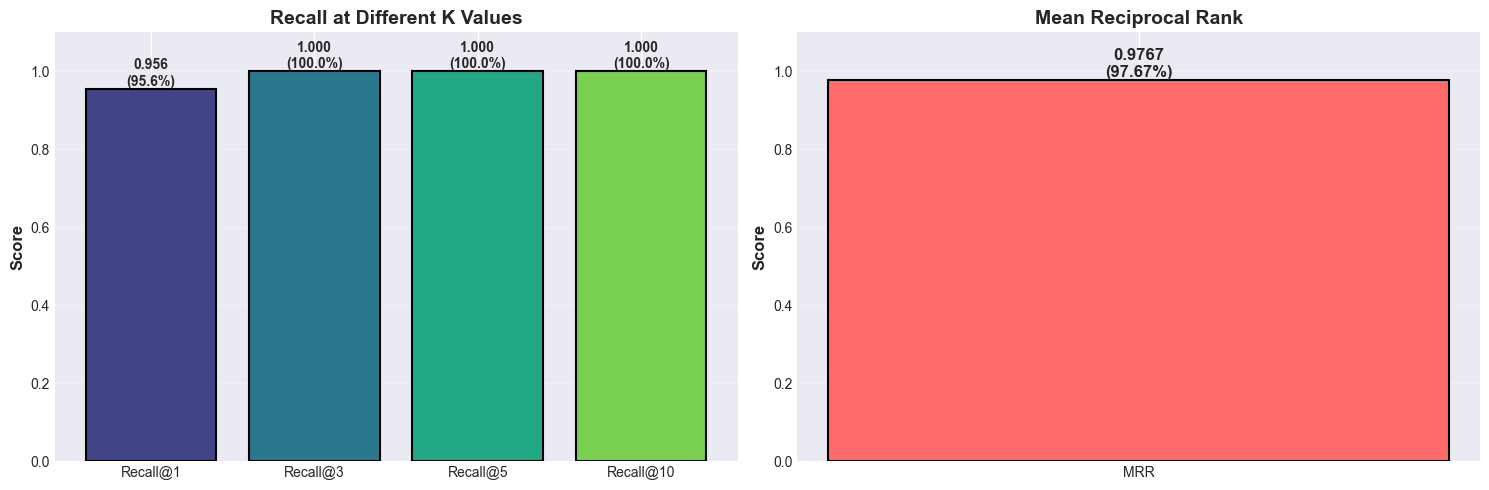

In [5]:
k_values = [1, 3, 5, 10]
recalls = [recall_at_k(ranked_lists, truths, k) for k in k_values]
mrr = mean_reciprocal_rank(ranked_lists, truths)

print("="*50)
print("PERFORMANCE METRICS")
print("="*50)
for k, recall in zip(k_values, recalls):
    print(f"Recall@{k:2d}: {recall:.4f} ({recall*100:.2f}%)")
print(f"MRR:       {mrr:.4f}")
print("="*50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

colors = sns.color_palette("viridis", len(k_values))
bars = ax1.bar([f"Recall@{k}" for k in k_values], recalls, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Recall at Different K Values', fontweight='bold', fontsize=14)
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3)

for bar, recall in zip(bars, recalls):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{recall:.3f}\n({recall*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

ax2.bar(['MRR'], [mrr], color='#FF6B6B', edgecolor='black', linewidth=1.5, width=0.4)
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Mean Reciprocal Rank', fontweight='bold', fontsize=14)
ax2.set_ylim([0, 1.1])
ax2.grid(axis='y', alpha=0.3)
ax2.text(0, mrr, f'{mrr:.4f}\n({mrr*100:.2f}%)',
        ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## Performance by Query Length

C:\Users\safwe\AppData\Local\Temp\ipykernel_10600\3830150439.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_performance = df_eval.groupby('length_bin').agg({


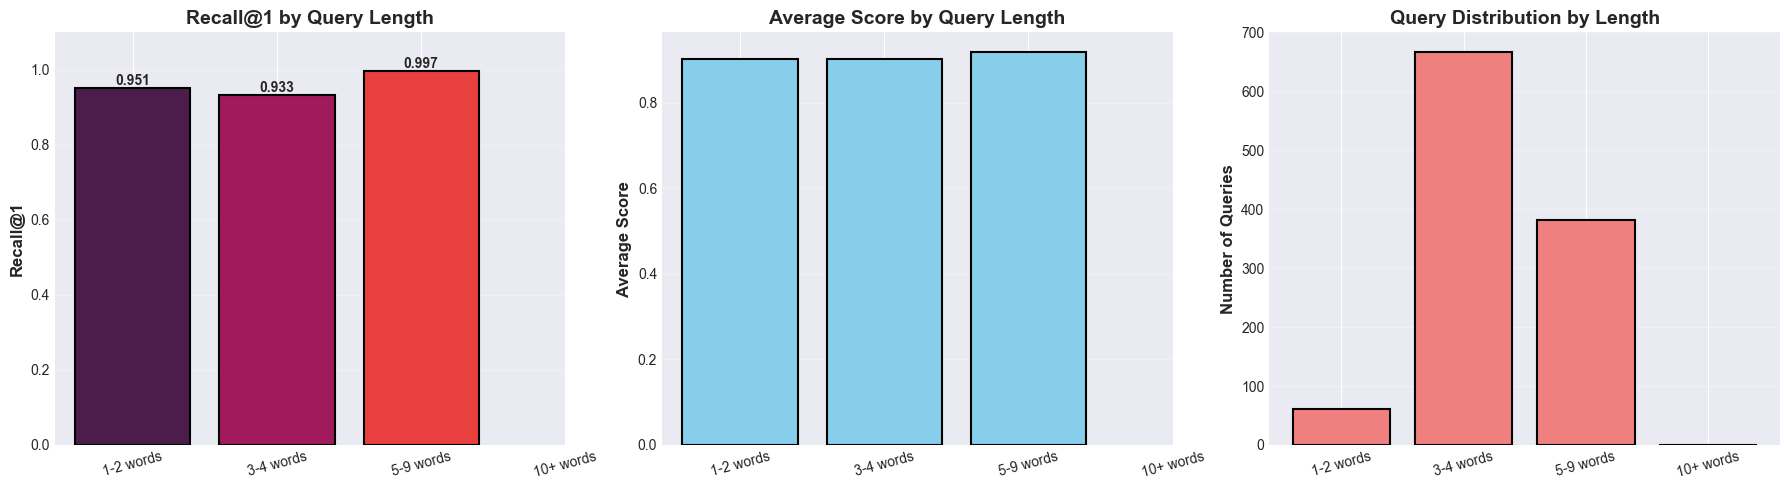


Performance by Query Length:
length_bin  is_correct    score  confidence  query_length
 1-2 words    0.950820 0.903275    0.854217            61
 3-4 words    0.932534 0.902363    0.853303           667
 5-9 words    0.997382 0.919354    0.866696           382
 10+ words         NaN      NaN         NaN             0


In [6]:
length_bins = [0, 3, 5, 10, 100]
length_labels = ['1-2 words', '3-4 words', '5-9 words', '10+ words']
df_eval = pd.DataFrame({
    'query_length': query_lengths,
    'correct_rank': correct_ranks,
    'score': all_scores,
    'confidence': all_confidences
})
df_eval['length_bin'] = pd.cut(df_eval['query_length'], bins=length_bins, labels=length_labels, include_lowest=True)
df_eval['is_correct'] = df_eval['correct_rank'].apply(lambda x: 1 if x == 1 else 0)

length_performance = df_eval.groupby('length_bin').agg({
    'is_correct': 'mean',
    'score': 'mean',
    'confidence': 'mean',
    'query_length': 'count'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars1 = axes[0].bar(range(len(length_performance)), length_performance['is_correct'],
                   color=sns.color_palette("rocket", len(length_performance)),
                   edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(length_performance)))
axes[0].set_xticklabels(length_performance['length_bin'], rotation=15)
axes[0].set_ylabel('Recall@1', fontweight='bold')
axes[0].set_title('Recall@1 by Query Length', fontweight='bold')
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars1, length_performance['is_correct'])):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}',
                ha='center', va='bottom', fontweight='bold')

axes[1].bar(range(len(length_performance)), length_performance['score'],
           color='skyblue', edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(length_performance)))
axes[1].set_xticklabels(length_performance['length_bin'], rotation=15)
axes[1].set_ylabel('Average Score', fontweight='bold')
axes[1].set_title('Average Score by Query Length', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(range(len(length_performance)), length_performance['query_length'],
           color='lightcoral', edgecolor='black', linewidth=1.5)
axes[2].set_xticks(range(len(length_performance)))
axes[2].set_xticklabels(length_performance['length_bin'], rotation=15)
axes[2].set_ylabel('Number of Queries', fontweight='bold')
axes[2].set_title('Query Distribution by Length', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPerformance by Query Length:")
print(length_performance.to_string(index=False))

## Summary Report

In [7]:
mode_counts = pd.Series(match_modes).value_counts()

print("="*70)
print("FINAL EVALUATION SUMMARY")
print("="*70)
print(f"\nDataset Statistics:")
print(f"  Total Queries: {len(df)}")
print(f"  Total Items in Catalog: {len(matcher.items)}")
print(f"\nOverall Performance:")
for k, recall in zip(k_values, recalls):
    print(f"  Recall@{k:2d}: {recall:.4f} ({recall*100:.2f}%)")
print(f"  MRR:       {mrr:.4f}")
print(f"\nScore Statistics:")
print(f"  Mean Score:      {np.mean(all_scores):.4f}")
print(f"  Median Score:    {np.median(all_scores):.4f}")
print(f"  Std Dev:         {np.std(all_scores):.4f}")
print(f"\nConfidence Statistics:")
print(f"  Mean Confidence: {np.mean(all_confidences):.4f}")
print(f"  Median Confidence: {np.median(all_confidences):.4f}")
print(f"  Std Dev:         {np.std(all_confidences):.4f}")
print(f"\nMatching Modes:")
for mode, count in mode_counts.items():
    print(f"  {mode.capitalize():15s}: {count:4d} ({count/len(match_modes)*100:5.1f}%)")
print(f"\nQueries with correct answer in top-1: {sum(1 for r in correct_ranks if r == 1)} ({sum(1 for r in correct_ranks if r == 1)/len(correct_ranks)*100:.1f}%)")
print(f"Queries with correct answer in top-5: {sum(1 for r in correct_ranks if r is not None and r <= 5)} ({sum(1 for r in correct_ranks if r is not None and r <= 5)/len(correct_ranks)*100:.1f}%)")
print("="*70)

FINAL EVALUATION SUMMARY

Dataset Statistics:
  Total Queries: 1110
  Total Items in Catalog: 111

Overall Performance:
  Recall@ 1: 0.9559 (95.59%)
  Recall@ 3: 1.0000 (100.00%)
  Recall@ 5: 1.0000 (100.00%)
  Recall@10: 1.0000 (100.00%)
  MRR:       0.9767

Score Statistics:
  Mean Score:      0.9083
  Median Score:    0.9137
  Std Dev:         0.0372

Confidence Statistics:
  Mean Confidence: 0.8580
  Median Confidence: 0.8644
  Std Dev:         0.0302

Matching Modes:
  Hybrid         : 1110 (100.0%)

Queries with correct answer in top-1: 1061 (95.6%)
Queries with correct answer in top-5: 1110 (100.0%)
